## 目标与运行方法

下载完整 `.ipynb`，在 VibeIt Studio 文件浏览器中使用 **+ → Import from Files** 导入并打开。按从上到下的顺序运行代码单元；阅读模式中的图表是已保存的真实运行输出。重新运行会从内嵌数据计算结果。

本课适合具备 Python 基础的本科生。先阅读每一步的方法与图注，再修改参数。AI 练习为可选部分，不需要 AI 账号即可完成核心课程。数据写在 notebook metadata 中，不需要另下载数据文件。请保持 notebook 已保存到当前工作文件夹。

学习任务是理解本课的研究问题、执行透明的计算、校验结果，并说明结论的边界。

## 环境与参数

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ec02-inflation'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### 读取内嵌快照

下面的加载函数按课程 ID 与 SHA-256 在当前文件夹定位本 notebook，解压后再次校验。文件改名不影响匹配。若找不到数据，确认当前工作目录与文件位置；不要用编造的数据替换它。metadata 随 `.ipynb` 保存及导出，复制代码到单独 `.py` 不会自动复制数据。

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'worldbank': 'd45779250297fb9371748b85b81321b2ae88f93ecf70cfb88256647a68e54376'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['worldbank']


### 方法函数

本课所需函数的完整代码就在下面。它们只使用已列出的预装包与标准库，运行时不会导入任何 cookbook 辅助模块。先检查输入约束和返回值；如果修改算法，后面的校验也需要继续通过。

In [3]:
def worldbank_panel(payload):
    """Preserve missing observations; official economy metadata excludes aggregates."""
    economies=pd.DataFrame(payload['economies']).set_index('iso3')
    observations=pd.DataFrame(payload['observations'])
    observations=observations[observations.iso3.isin(economies.index)].copy()
    if observations.duplicated(['iso3','year','indicator']).any():raise ValueError('Duplicate economy/year/indicator observations')
    observations['value']=pd.to_numeric(observations.value,errors='raise')
    wide=observations.pivot(index=['iso3','year'],columns='indicator',values='value').sort_index()
    return wide,economies,observations

print("Method ready: worldbank_panel")


Method ready: worldbank_panel


### 数据与模型边界

World Bank 记录保留定义、缺失观测及参考年。六个经济体为声明例子，不是全球随机样本。国家均值、价格篮子换算和 Gini 指数描述不同量，调查概念及覆盖可能不同。

## 分步分析

### 1. 声明价格指数和假设金额

使用美国 CPI 并重定有效 2010 基值。不变名义 1000 美元为教学输入，不是编造工资/家庭收入数据。

Economy/year records: 3255 ; official aggregates excluded; missing values preserved


,name,region,income_group
iso3,,,
CHN,China,East Asia & Pacific,Upper middle income
USA,United States,North America,High income
DEU,Germany,Europe & Central Asia,High income
BRA,Brazil,Latin America & Caribbean,Upper middle income
IND,India,South Asia,Lower middle income
ZAF,South Africa,Sub-Saharan Africa,Upper middle income


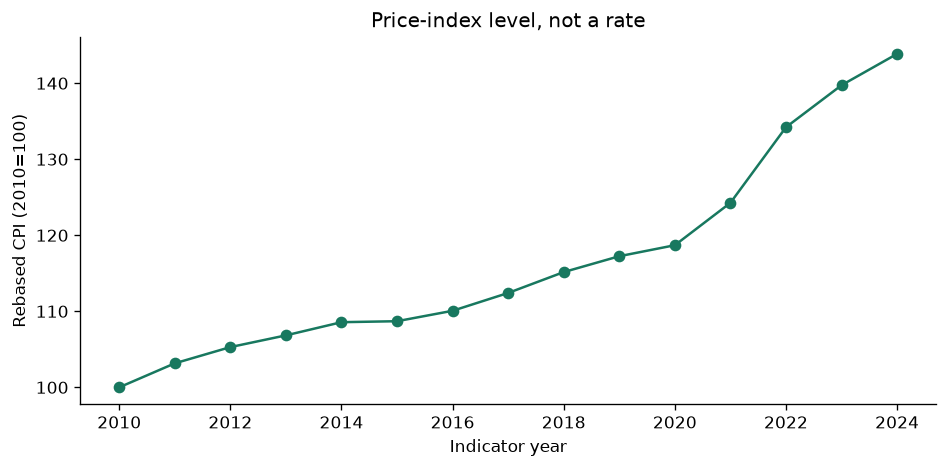

In [4]:
wb=snapshot("worldbank");panel,economies,observations=worldbank_panel(wb)
countries=["CHN","USA","DEU","BRA","IND","ZAF"]
assert set(countries)<=set(economies.index)
print("Economy/year records:",len(panel),"; official aggregates excluded; missing values preserved")
display(economies.loc[countries,["name","region","income_group"]])
cpi=panel.loc["USA","FP.CPI.TOTL"].reindex(range(2010,2025))
reported=panel.loc["USA","FP.CPI.TOTL.ZG"].reindex(cpi.index)
assert cpi.loc[2010]>0
rebased=100*cpi/cpi.loc[2010];nominal=1000.0
fig,ax=plt.subplots(figsize=(8,4));ax.plot(rebased.index,rebased,"o-")
ax.set(xlabel="Indicator year",ylabel="Rebased CPI (2010=100)",title="Price-index level, not a rate");plt.tight_layout();plt.show()


### 2. 核对计算及已发布变化率

使用相邻有效年。来源修订/舍入可能产生差异，应公开而非强制一致；变化率之差为百分点。

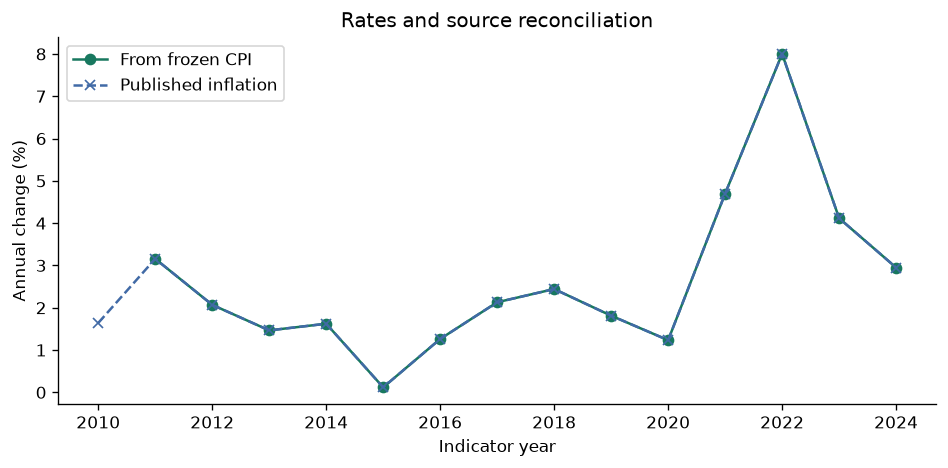

,computed_percent,reported_percent,difference_percentage_points
year,,,
2018,2.442583,2.442583,9.325873e-15
2019,1.812210,1.812210,3.563816e-13
2020,1.233584,1.233584,-5.031531e-13
2021,4.697859,4.697859,-3.730349e-14
2022,8.002800,8.002800,6.235013e-13
2023,4.116338,4.116338,-2.149392e-13
2024,2.949525,2.949525,-2.593481e-13


In [5]:
computed=100*cpi.pct_change(fill_method=None)
fig,ax=plt.subplots(figsize=(8,4));ax.plot(computed.index,computed,"o-",label="From frozen CPI")
ax.plot(reported.index,reported,"x--",label="Published inflation")
ax.set(xlabel="Indicator year",ylabel="Annual change (%)",title="Rates and source reconciliation");ax.legend();plt.tight_layout();plt.show()
comparison=pd.DataFrame({"computed_percent":computed,"reported_percent":reported,"difference_percentage_points":computed-reported})
display(comparison.tail(7))


### 3. 换算 CPI 实值金额

名义美元除以重定 CPI/100。结果使用广义来源价格篮子，不是个人生活成本或投资盈利。

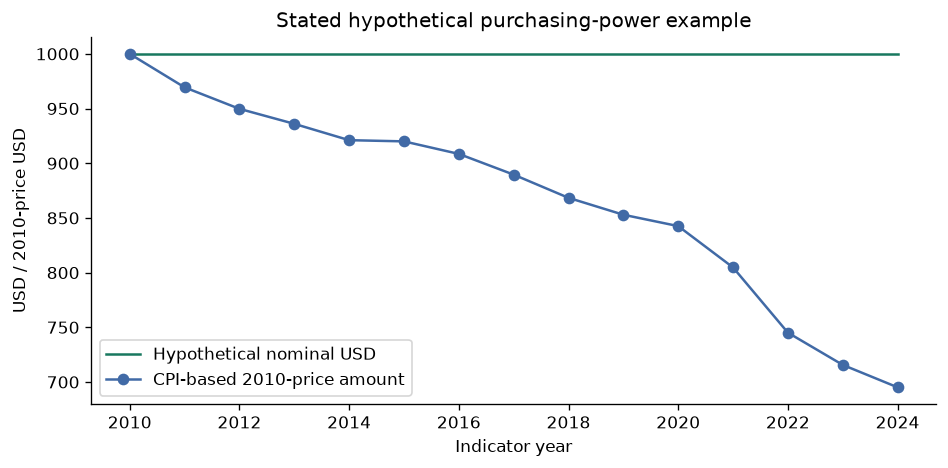

In [6]:
real=nominal*100/rebased
fig,ax=plt.subplots(figsize=(8,4));ax.plot(cpi.index,np.full(len(cpi),nominal),label="Hypothetical nominal USD")
ax.plot(real.index,real,"o-",label="CPI-based 2010-price amount")
ax.set(xlabel="Indicator year",ylabel="USD / 2010-price USD",title="Stated hypothetical purchasing-power example");ax.legend();plt.tight_layout();plt.show()


### 4. 检查重定并导出假设

基年名义/实值一致。保留原 CPI 及派生指数；固定名义例子不测量收入变化。

In [7]:
assert np.isclose(rebased.loc[2010],100) and np.isclose(real.loc[2010],nominal) and pd.isna(computed.loc[2010])
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"source_CPI":cpi,"rebased_2010_100":rebased,"hypothetical_nominal_USD":nominal,"CPI_based_2010_price_USD":real}).to_csv(OUTPUT_DIR/"price-and-real-amount.csv")
comparison.to_csv(OUTPUT_DIR/"inflation-reconciliation.csv")
print("Rebasing checked; maximum discrepancy (percentage points):",float(comparison.difference_percentage_points.abs().max()))


Rebasing checked; maximum discrepancy (percentage points): 6.235012506294879e-13


## 自主练习与参考答案

1. 区分指数与通胀率。
2. 金额为何是假设？

**参考解释。** 率比较相邻水平；金额为声明输入，不是收入观测。

先保留当前 notebook 副本，再修改参数。把新图与原图一起比较，并记录改变了哪些输入、哪些计算和哪些结论。

## 可选的 AI 编程练习

在 VibeIt 的 Coding Agent 中打开当前 notebook，先让助手阅读相关单元。核心课程不依赖 AI 服务；服务可用性与账号设置以应用帮助中心为准。

**提示词 1**

> 仅用 NumPy、Pandas、Matplotlib 重定至 2020 并重标实值单位。

**提示词 2**

> 同包增加另一声明经济体的观测 CPI。

**人工验收。** 不填缺失，率差用百分点，基年金额一致。

检查修改后的源代码，再手动运行受影响单元及后续校验。要求助手解释修改的目的、使用的包和数据来源，并用实际输出核对解释。

## 可选联网扩展

默认关闭下面的联网操作。它只显示数据库版本及快照来源，不会替换核心数据。若要重新获取数据，应另存一个实验版本并记录新的 URL、数据库版本、获取日期与 SHA-256；新版结果需要重新执行和核验。

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://api.worldbank.org/v2/indicator/NY.GDP.PCAP.KD?format=json',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## 来源、快照与下一步

- [World Bank economy metadata](https://api.worldbank.org/v2/country?format=json&per_page=400) — World Bank CC BY 4.0 with additional terms; retain original indicator attribution; retrieved 2026-10-09. SHA-256 `c9acf3932785191a649cbc04c3056af4cf64a236e5c3b49d49be25ddb0440bce`.
  Preserve economy IDs, region and income-group metadata; exclude aggregates in student analyses.

- [World Bank NY.GDP.PCAP.KD](https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.KD?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `59a9efaf20ab359c7832f24da45dda2282511c0eaf927d044583f47d08e02cda`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata NY.GDP.PCAP.KD](https://api.worldbank.org/v2/indicator/NY.GDP.PCAP.KD?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `46689488cd435920647264ede1bfb2d4b51b09800fb36f3d3b1422a0b11ea49d`.
  Preserve indicator definition, source organization and source note.

- [World Bank NY.GDP.MKTP.KD](https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.KD?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `466f4e3176b509613f3df99acffce89b5f1ea14472c376dd10d8b8f67f6172b0`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata NY.GDP.MKTP.KD](https://api.worldbank.org/v2/indicator/NY.GDP.MKTP.KD?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `bc4bc0ffec1755410f52b1091c6b1f46917c7417977102350d3d1102b4659216`.
  Preserve indicator definition, source organization and source note.

- [World Bank SP.POP.TOTL](https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `7ecf8d749dbddd87a269f2019e6d42ed32875c57565cf5c5af097c6e6c9af528`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata SP.POP.TOTL](https://api.worldbank.org/v2/indicator/SP.POP.TOTL?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `2f8491efc00bf2c0995112ff8e87aba69e5e9d22d0880b22f7e3a4ec757ba05c`.
  Preserve indicator definition, source organization and source note.

- [World Bank SP.DYN.LE00.IN](https://api.worldbank.org/v2/country/all/indicator/SP.DYN.LE00.IN?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `d8b5c6bd7fecaf8cee0e422444719ba1f42ec70996308bc74afd14ee48799055`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata SP.DYN.LE00.IN](https://api.worldbank.org/v2/indicator/SP.DYN.LE00.IN?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `a39cb6fddfbbb953053690366243dffe77a266c4deae79c46ce5a06da9f5fc31`.
  Preserve indicator definition, source organization and source note.

- [World Bank FP.CPI.TOTL](https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `55c3b71ad4dd8c92c15fa7dc2b502a3d60f26cf47ae9a24e384bc2ff6108ff56`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata FP.CPI.TOTL](https://api.worldbank.org/v2/indicator/FP.CPI.TOTL?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `13b1e3c4b2b72f7fb3a630b4dde37f0e68e6d5e78dc06b2437dfea0c0b93af46`.
  Preserve indicator definition, source organization and source note.

- [World Bank FP.CPI.TOTL.ZG](https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL.ZG?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `849b6a88a84a7efdeb92d89e8db1db36f86543e28ff8eb645e0feaa8c634def7`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata FP.CPI.TOTL.ZG](https://api.worldbank.org/v2/indicator/FP.CPI.TOTL.ZG?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `df9371a3b6c01e55a3f28991e62e1b1ebbe0cd2a7da94456be9938c7a2962233`.
  Preserve indicator definition, source organization and source note.

- [World Bank SI.POV.GINI](https://api.worldbank.org/v2/country/all/indicator/SI.POV.GINI?date=2010:2024&format=json&per_page=20000&footnote=y) — World Bank CC BY 4.0 with additional terms; original sources retained in indicator metadata; retrieved 2026-10-09. SHA-256 `4919413d3b9ef06b7445c3fd42d47b8a09e9836bbab7be84e4993099ffdc7ab2`.
  Retain official observations including null values and footnotes, 2010–2024; no interpolation; no aggregate-country mixing.

- [World Bank indicator metadata SI.POV.GINI](https://api.worldbank.org/v2/indicator/SI.POV.GINI?format=json) — World Bank CC BY 4.0 with additional terms; retrieved 2026-10-09. SHA-256 `e377bf82b38024748153880ff90c0106a0ef0fd8cb04761146cc60a2609cab3d`.
  Preserve indicator definition, source organization and source note.


**下一步。** 在保留本课的数据检查、参数记录和结果校验之后，将相同方法用于自己的公开或已获授权数据。记录研究设计与方法限制，不把示例结果当成新实验的验证。完整数据许可与生成说明见 cookbook 网页。